Los límites del intervalo son: (-0.09, 0.0905555555555558) días.
La estimación del flujo relativo en t = -0.025 es: 0.9805630405986296.


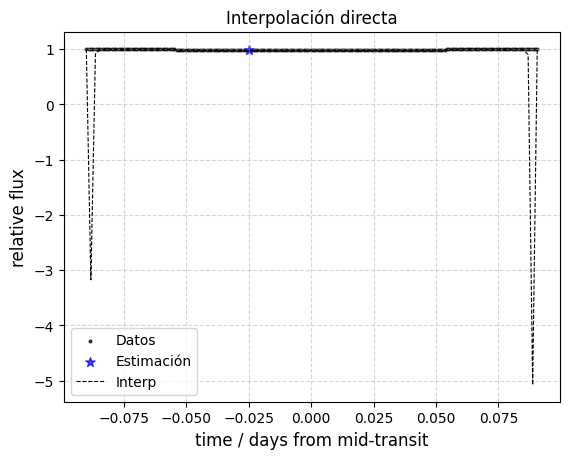

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Implementación del pseudocódigo de la matriz de Valdermore
def vandermonde(x_datos):
    n = len(x_datos)
    v = np.zeros((n,n))

    for i in range(n):
        for j in range(n):
            v[i][j] = x_datos[i]**j

    return v

# Implementación del pseudocódigo para la eliminación gaussiana
def gauss_solve(A, b):  # Ax = b
    n = len(b)
    M = np.column_stack((A,b)).astype(float)
    for k in range(n):
        # Pivoteo parcial: buscar el elemento de mayor valor absoluto en una columna dada k
        piv = k + np.argmax(np.abs(M[k:, k]))  
        M[[k, piv]] = M[[piv, k]]

        # Esto es para comprobar si algún pivote resulta siendo muy cercano a cero, complicando los cálculos numéricos para matrices grandes
        # if np.isclose(M[k, k], 0):
        #     raise ValueError("Pivote cero: sistema singular o mal condicionado")

        # Eliminación hacia abajo:
        for i in range(k+1, n):
            factor = M[i, k] / M[k, k]
            for j in range(k, n+1):
                M[i, j] = M[i, j] - factor * M[k, j]

    # Sustitución hacia arriba:
    x = np.zeros(n)
    for i in range(n-1, -1, -1):  # n, n-1, n-2, ..., 1, 0
        suma = 0 
        for j in range(i+1, n):
            suma = suma + M[i, j] * x[j]
        x[i] = (M[i, n] - suma) / M[i, i]
    return x

def interp_directa(x_datos, y_datos, x_eval):
    v = vandermonde(x_datos)
    a = gauss_solve(v, y_datos)

    resultado = 0
    for i in range(len(a)):
        resultado = resultado + a[i] * (x_eval**i)

    y_eval = resultado

    # Devuelve los coeficientes de la función polinómica y la estimación del valor f(x_eval)=y_eval
    return a, float(y_eval) 

# Una función para calcular cualquier otra estimación con los coeficientes obtenidos
def pol(x, a):
    resultado = 0
    for i in range(len(a)):
        resultado = resultado + a[i] * (x**i)
    return resultado


# Para los datos proporcionados:

data = np.load("data.npy")

time = np.array(data[:, 0])
flux = np.array(data[:, 1])
flux_uncertainty = data[:, 2]

t_eval = -0.025

a, flux_eval = interp_directa(x_datos=time, y_datos=flux, x_eval=t_eval)

t_interp = np.linspace(time[0], time[-1], 100)

print(f"Los límites del intervalo son: ({time[0]}, {time[-1]}) días.")
print(f"La estimación del flujo relativo en t = {t_eval} es: {flux_eval}.")

# Graficar
plt.figure()
plt.scatter(time, flux, color='k', marker=".", s=15, alpha=0.7, label= "Datos")
plt.scatter(t_eval, flux_eval, color='b', marker="*", s=50, alpha=0.7, label= "Estimación")
plt.plot(t_interp, pol(t_interp, a), "k--", linewidth=0.8, label="Interp")
plt.xlabel("time / days from mid-transit", fontsize=12)
plt.ylabel("relative flux", fontsize=12)
plt.grid(linestyle='--', alpha=0.5)
plt.legend()
plt.title("Interpolación directa")
plt.show()



Los límites del intervalo son: (-2.0, 2.0) días.
La estimación del flujo relativo en t = -0.025 es: 0.920257987062665.


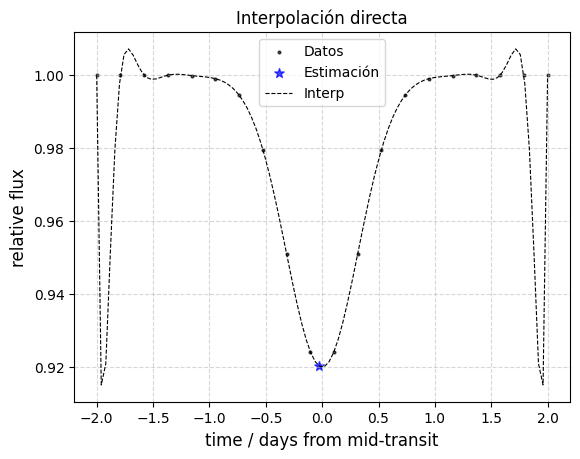

In [26]:
# Para una serie de datos más pequeña:

data = np.load("data_prueba.npy")

time = np.array(data[:, 0])
flux = np.array(data[:, 1])
flux_uncertainty = data[:, 2]

t_eval = -0.025

a, flux_eval = interp_directa(x_datos=time, y_datos=flux, x_eval=t_eval)

t_interp = np.linspace(time[0], time[-1], 100)

print(f"Los límites del intervalo son: ({time[0]}, {time[-1]}) días.")
print(f"La estimación del flujo relativo en t = {t_eval} es: {flux_eval}.")

# Graficar
plt.figure()
plt.scatter(time, flux, color='k', marker=".", s=15, alpha=0.7, label= "Datos")
plt.scatter(t_eval, flux_eval, color='b', marker="*", s=50, alpha=0.7, label= "Estimación")
plt.plot(t_interp, pol(t_interp, a), "k--", linewidth=0.8, label="Interp")
plt.xlabel("time / days from mid-transit", fontsize=12)
plt.ylabel("relative flux", fontsize=12)
plt.grid(linestyle='--', alpha=0.5)
plt.legend()
plt.title("Interpolación directa")
plt.show()